## Setup
For sure, we'll need pandas, matplotlib, and yfinance.  
Other options are available - for example analysis using R and visualization using PowerBI or whatever, but this is what I know.  


In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import numpy as np

## Data Pull
List of assets/tickers to pull data from.  
Default probably Apple, Sandisk, Bitcoin.  

In [249]:
# Assets of interest and their tickers - populate if unknown
# Not very well done, and you should probably know the ticker, but still.
# assets = {
#     "Apple":None,
#     "Bitcoin":None,
#     "Sandisk":None
# }

# for asset in assets:
#     search_results = yf.Search(asset)
#     # Just gonna assume the first result is what we want and not look any further into it
#     assets[asset] = search_results.all['quotes'][0]['symbol']

# In fact, never mind! Let's hard code these bitches.
assets = ['AAPL', 'SPY', 'CL=F'] # 'SNDK', 'CL=F'] #BTC-USD']

In [250]:
# Time periods of interest for rolling averages and trends - updates to current day.
# END_DATE = datetime.today().strftime('%Y-%m-%d')
# START_DATE_1Y = (datetime.today() - timedelta(days=365)).strftime('%Y-%m-%d')
# START_DATE_5Y = (datetime.today() - timedelta(days=365*5)).strftime('%Y-%m-%d')
# yf.download has a period field, so that was a waste lol

In [251]:
# # lol no, bulk download function
# for asset in assets:
#     ticker = yf.Ticker(assets[asset])
#     df_1y = ticker.history(period='1y')
#     df_5y = ticker.history(period='5y')

# And do I actually care about the 5-year? Not really.
# I also only really care about the close price for now.
df = yf.download(assets, period="1y")['Close'] # start=START_DATE_1Y, end=END_DATE)
# df5 = yf.download(list(assets.values()), start=START_DATE_5Y, end=END_DATE)

[*********************100%***********************]  3 of 3 completed


## Core Analysis
I'm no superstar with financial info, but...  
- Long/short moving averages
- Trend direction
- Volatility via std deviation

In [252]:
# Easy rolling method, but let's just calculate it for the thrill and then compare
# def rolling():
#     pass
# I'm trying to make decisions, not futz around reimplementing simple mathematics.    

In [253]:
# df1.dropna(how='all', inplace=True)
# df5.dropna(how='all', inplace=True)

In [254]:
# # Probably just care about the close price, yeah?
# rolling_1_50 = df1['Close'].rolling(50, min_periods=1).mean()
# rolling_1_200 = df1['Close'].rolling(200, min_periods=1).mean()
# rolling_5_50 = df5['Close'].rolling(50, min_periods=1).mean()
# rolling_5_200 = df5['Close'].rolling(200, min_periods=1).mean()

# print(rolling_1_50.tail())
# rolling_1_200.tail()

short_window = 50
long_window = 200
min_period = 1 # so the average starts counting immediately

ma_short = df.rolling(short_window, min_periods=min_period).mean()
ma_long = df.rolling(long_window, min_periods=min_period).mean()

volatility = df.pct_change().rolling(window=20).std() # less familiar with this so eh

In [281]:
# ==============
# INTERPRETATION
# ==============
def summarize(asset, df, ma_short, ma_long, volatility):
    message = f"\n"
    
    latest_price = df[asset].iloc[-1]
    short = ma_short[asset].iloc[-1]
    long = ma_long[asset].iloc[-1]
    vol = volatility[asset].iloc[-1]

    trend = "Bullish" if short > long else "Bearish"
    vol_level = "High" if vol > volatility[asset].mean() else "Low" # Maybe 'medium' or 'moderate' fit better here

    slope, _, _, _ = linear_trend(asset)
    
    message = f"""=== {asset} Analysis ===
Price:\t\t{latest_price:.2f}
\tMA (short:long): {short:.2f}:{long:.2f}
Trend:\t\t{trend} signal
\tRegression slope: {slope:.3f}
Volatility:\t{vol_level} (Current: {vol:.3f}\tAverage: {volatility[asset].mean():.3f})
"""

    return message

# =======
# LIN REG
# =======
def linear_trend(asset, window=30):
    # zzz
    s = df[asset].dropna().iloc[-window:]
    y = s.values
    x = np.arange(len(s))

    slope, intercept = np.polyfit(x, y, 1)
    #trend = "Upward" if slope > 0 else "Downward"
    trend_line = slope * x + intercept
    
    return slope, intercept, trend_line, s.index # needed because of all the NaNs

In [282]:
print(summarize('SPY', df, ma_short, ma_long, volatility))

=== SPY Analysis ===
Price:		704.08
	MA (short:long): 674.84:664.10
Trend:		Bullish signal
	Regression slope: 1.476
Volatility:	High (Current: 0.011	Average: 0.008)



In [259]:
# =======
# SIGNALS
# =======
# MA Crossover
signal = (ma_short > ma_long).astype(int) # 1 => short term shooting up, bullish, 0 bearish

# Specific Crossover Points
crossover = signal.diff().dropna()
# just awful in the plt
# cross_bullish = crossover[crossover > 0].dropna(how='all') #, inplace=True)
# cross_bearish = crossover[crossover < 0].dropna(how='all') #, inplace=True)

# Volatility Flag
v_flag = volatility > volatility.rolling(20).mean()


## Basic Forecast
- Linear regression; basic ML, doesn't even need one of the heavy-hitter libraries
- Rolling average projection


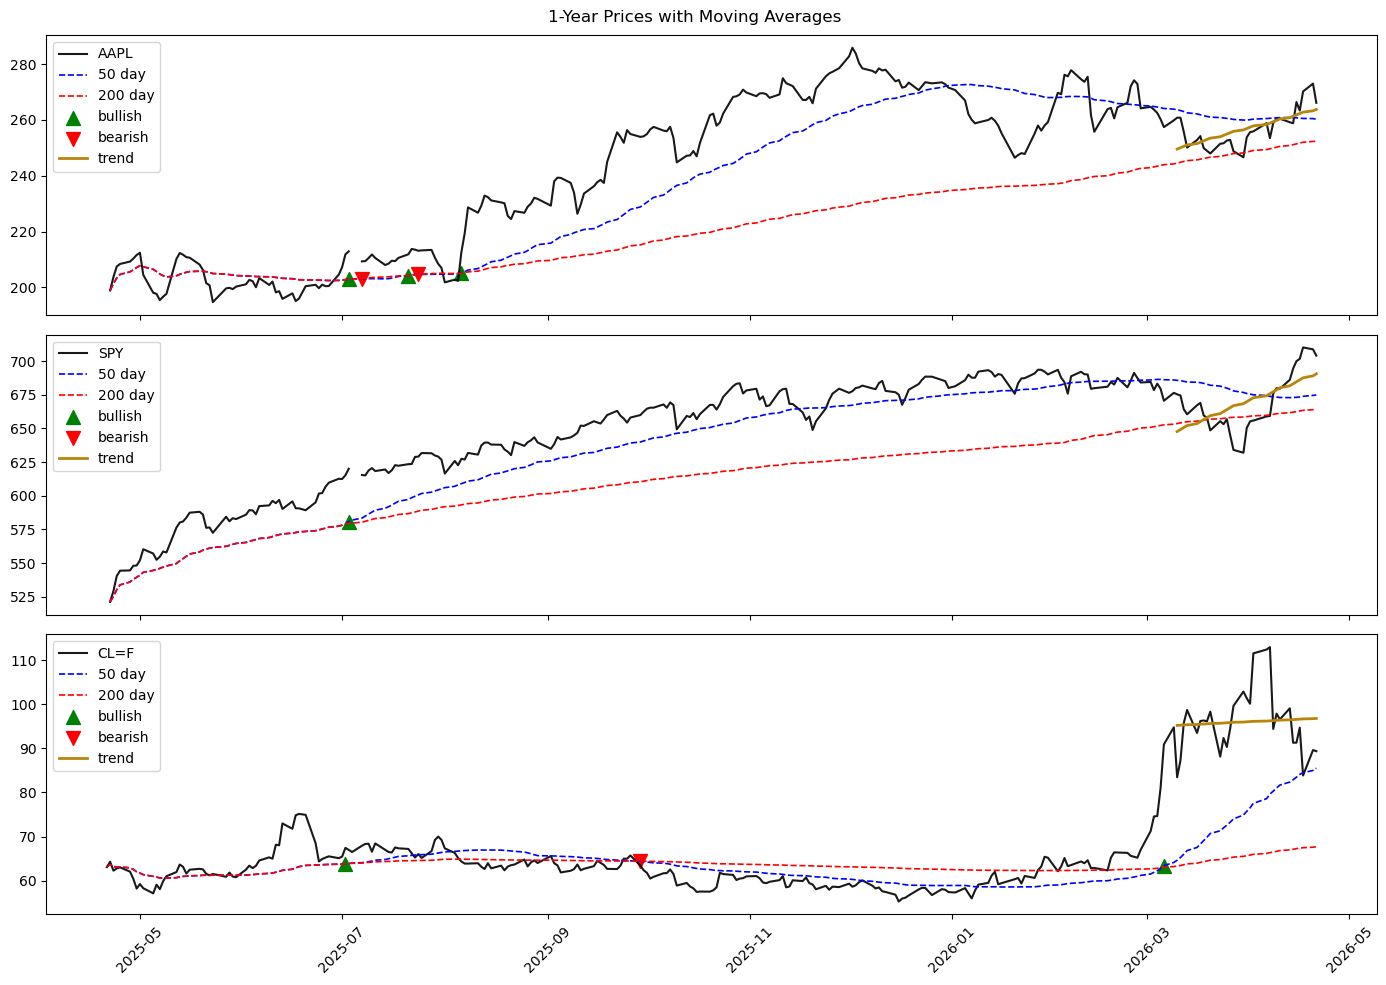

In [280]:
# ========
# PLOTTING
# ========
regression_window = 30
colors = ('black', 'blue', 'red')

fig, axes = plt.subplots(len(assets), 1, figsize=(14, 10), sharex=True)
plt.suptitle("1-Year Prices with Moving Averages")


# eh, looks like I'm hardcoding 3 colors lol
# and 1-year, should shove this into a function I reckon
for ax, asset in zip(axes, assets):
    ax.plot(df.index, df[asset], label=asset, color=colors[0],
            linewidth=1.5, alpha=0.9)
    ax.plot(df.index, ma_short[asset], label='50 day', color=colors[1], 
            linewidth=1.2, linestyle='--')
    ax.plot(df.index, ma_long[asset], label='200 day', color=colors[2],
            linewidth=1.2, linestyle='--')

    crossover_bull_index = crossover[asset][crossover[asset] > 0].index
    crossover_bear_index = crossover[asset][crossover[asset] < 0].index
    
    ax.scatter(crossover_bull_index, 
               ma_short.loc[crossover_bull_index, asset], marker="^",
               label="bullish", s=100, color='green')
    ax.scatter(crossover_bear_index, 
               ma_short.loc[crossover_bear_index, asset], marker="v",
               label="bearish", s=100, color='red')

    slope, intercept, trend_line, trend_index = linear_trend(asset, 
                                                             window=regression_window)
    # aligning regression segment to the window - doesn't always need to be max!
    # x_trend = df.index[-regression_window:]
    ax.plot(trend_index, trend_line, color="darkgoldenrod", linewidth=2, label="trend")
    
    
    # ax.set_ylabel('Price', fontsize=11)
    ax.legend(loc='upper left')
    # ax.yaxis.set_major_formatter('${x:.0f}')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    

## Output
- Chart
- Printed insight


In [283]:
for asset in assets:
    print(summarize(asset, df, ma_short, ma_long, volatility))
    print()

=== AAPL Analysis ===
Price:		266.17
	MA (short:long): 260.27:252.40
Trend:		Bullish signal
	Regression slope: 0.490
Volatility:	High (Current: 0.015	Average: 0.014)


=== SPY Analysis ===
Price:		704.08
	MA (short:long): 674.84:664.10
Trend:		Bullish signal
	Regression slope: 1.476
Volatility:	High (Current: 0.011	Average: 0.008)


=== CL=F Analysis ===
Price:		89.37
	MA (short:long): 85.51:67.70
Trend:		Bullish signal
	Regression slope: 0.055
Volatility:	High (Current: 0.064	Average: 0.025)




In [ ]:
# TODO
# better volatility checks lol
# bollinger bands
# relative strength index
# splitting files
# toggle markers
# back to generalizing over however many tickers